In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [62]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

In [63]:

df = pd.read_csv("Solar data.csv")

df.head()

,Date,Time,DateTime,Country,DC_Power,AC_Power,Ambient_Temperature,Module_Temperature,Irradiation,Day,Month,Hour,Daily_Yield,Total_Yield
0,2024-01-01,0,2024-01-01 00:00:00,Norway,0.0,0.0,-10.15,-3.33,0.039,1,1,0,145.722,145.722
1,2024-01-01,1,2024-01-01 01:00:00,Norway,0.0,0.0,-10.06,-3.50,0.014,1,1,1,145.722,291.444
2,2024-01-01,2,2024-01-01 02:00:00,Norway,0.0,0.0,-9.95,-5.17,0.025,1,1,2,145.722,437.166
3,2024-01-01,3,2024-01-01 03:00:00,Norway,0.0,0.0,-9.27,-4.53,0.000,1,1,3,145.722,582.888
4,2024-01-01,4,2024-01-01 04:00:00,Norway,0.0,0.0,-9.62,-6.34,0.000,1,1,4,145.722,728.610


In [64]:
print(df.shape)
print(df.columns)

(35136, 14)
Index(['Date', 'Time', 'DateTime', 'Country', 'DC_Power', 'AC_Power',
       'Ambient_Temperature', 'Module_Temperature', 'Irradiation', 'Day',
       'Month', 'Hour', 'Daily_Yield', 'Total_Yield'],
      dtype='object')


In [65]:
df.drop(['DateTime','Day','Month', 'Hour',], inplace= True ,axis = 1)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35136 entries, 0 to 35135
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 35136 non-null  object 
 1   Time                 35136 non-null  int64  
 2   Country              35136 non-null  object 
 3   DC_Power             35136 non-null  float64
 4   AC_Power             35136 non-null  float64
 5   Ambient_Temperature  35136 non-null  float64
 6   Module_Temperature   35136 non-null  float64
 7   Irradiation          35136 non-null  float64
 8   Daily_Yield          35136 non-null  float64
 9   Total_Yield          35136 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 2.7+ MB


In [67]:
print(df.columns)

Index(['Date', 'Time', 'Country', 'DC_Power', 'AC_Power',
       'Ambient_Temperature', 'Module_Temperature', 'Irradiation',
       'Daily_Yield', 'Total_Yield'],
      dtype='object')


In [68]:
print(df.isna().sum())
print("Duplicates:", df.duplicated().sum())

Date                   0
Time                   0
Country                0
DC_Power               0
AC_Power               0
Ambient_Temperature    0
Module_Temperature     0
Irradiation            0
Daily_Yield            0
Total_Yield            0
dtype: int64
Duplicates: 0


array([[<Axes: title={'center': 'Time'}>,
        <Axes: title={'center': 'DC_Power'}>,
        <Axes: title={'center': 'AC_Power'}>],
       [<Axes: title={'center': 'Ambient_Temperature'}>,
        <Axes: title={'center': 'Module_Temperature'}>,
        <Axes: title={'center': 'Irradiation'}>],
       [<Axes: title={'center': 'Daily_Yield'}>,
        <Axes: title={'center': 'Total_Yield'}>, <Axes: >]], dtype=object)

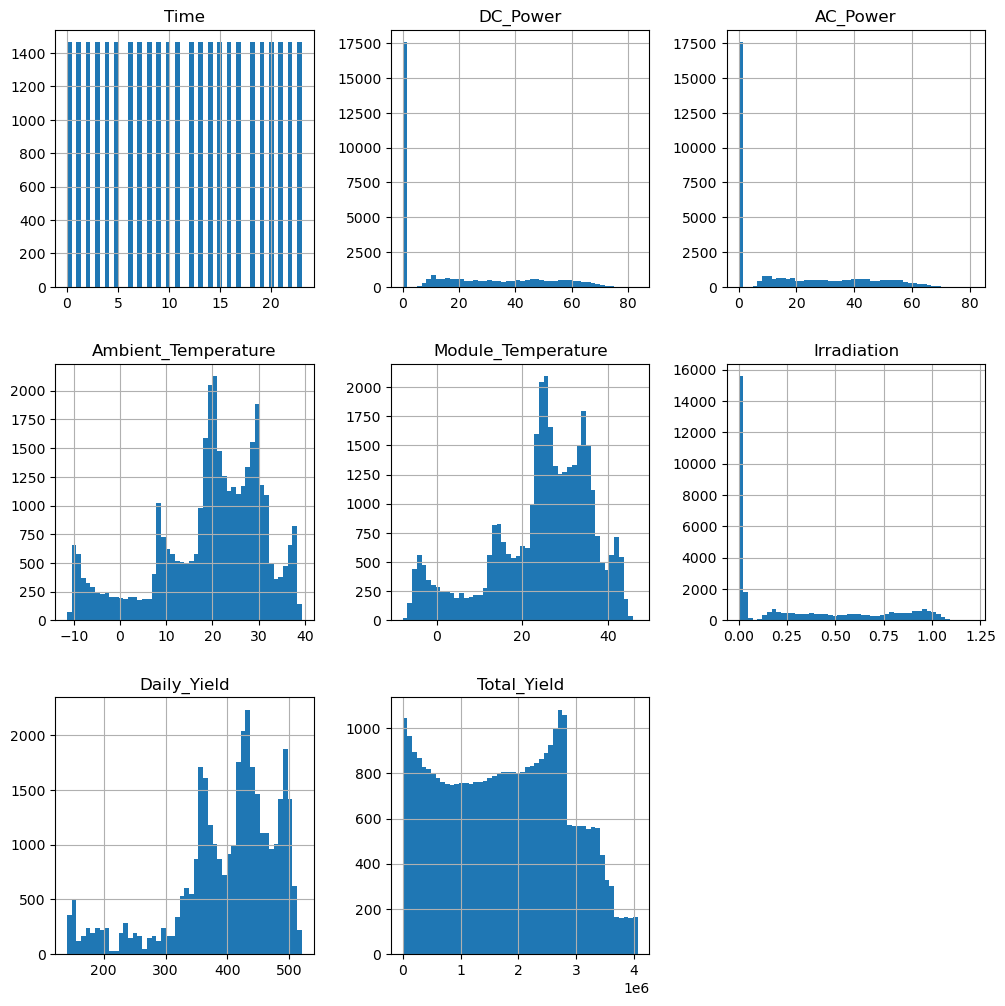

In [69]:
df.describe()

df.hist(bins= 50, figsize=(12,12))

In [70]:
df["Date"] = pd.to_datetime(df["Date"])
print(df['Date'].head())


0   2024-01-01
1   2024-01-01
2   2024-01-01
3   2024-01-01
4   2024-01-01
Name: Date, dtype: datetime64[ns]


In [71]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

In [72]:
df.drop(['Date'],inplace= True,axis = 1)

In [73]:
print(df.columns)

Index(['Time', 'Country', 'DC_Power', 'AC_Power', 'Ambient_Temperature',
       'Module_Temperature', 'Irradiation', 'Daily_Yield', 'Total_Yield',
       'year', 'month', 'day'],
      dtype='object')


In [74]:
df = pd.get_dummies(df, columns=['Country'])

In [75]:
df.head()

,Time,DC_Power,AC_Power,Ambient_Temperature,Module_Temperature,Irradiation,Daily_Yield,Total_Yield,year,month,day,Country_Australia,Country_Brazil,Country_India,Country_Norway
0,0,0.0,0.0,-10.15,-3.33,0.039,145.722,145.722,2024,1,1,False,False,False,True
1,1,0.0,0.0,-10.06,-3.50,0.014,145.722,291.444,2024,1,1,False,False,False,True
2,2,0.0,0.0,-9.95,-5.17,0.025,145.722,437.166,2024,1,1,False,False,False,True
3,3,0.0,0.0,-9.27,-4.53,0.000,145.722,582.888,2024,1,1,False,False,False,True
4,4,0.0,0.0,-9.62,-6.34,0.000,145.722,728.610,2024,1,1,False,False,False,True


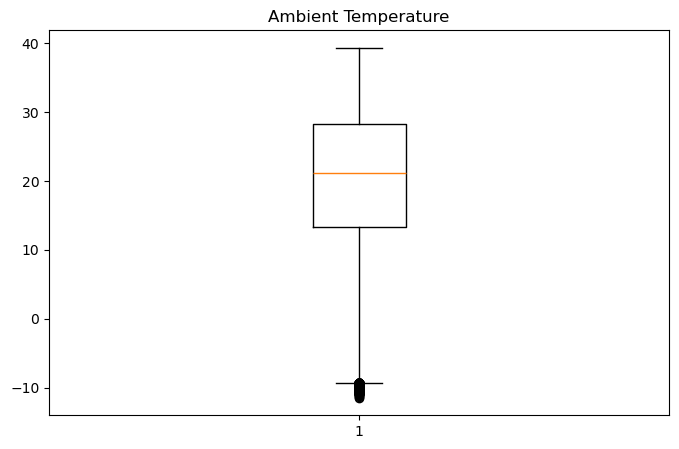

In [76]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Ambient_Temperature"])
plt.title("Ambient Temperature")

plt.show()

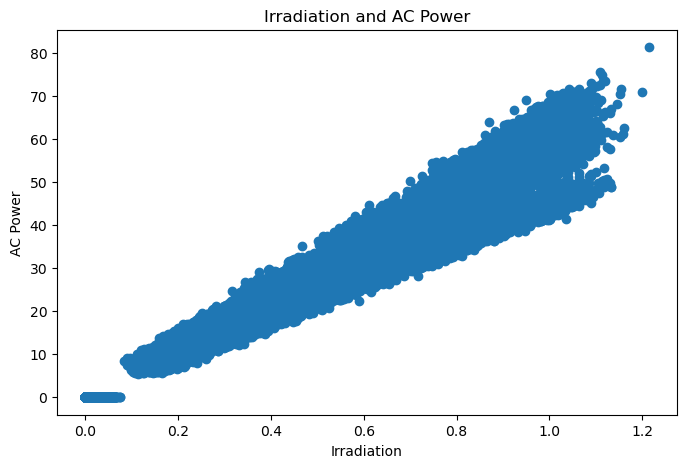

In [77]:
plt.figure(figsize=(8,5))

plt.scatter(df["Irradiation"], df["AC_Power"])

plt.xlabel("Irradiation")
plt.ylabel("AC Power")

plt.title("Irradiation and AC Power")

plt.show()

In [78]:
corr_matrix = df.corr()

In [79]:
corr_matrix["Daily_Yield"].sort_values(ascending=False)

Daily_Yield            1.000000e+00
Ambient_Temperature    5.623981e-01
Module_Temperature     5.605665e-01
Country_Brazil         4.331884e-01
AC_Power               1.750839e-01
DC_Power               1.729377e-01
Irradiation            1.338439e-01
Country_Australia      1.120198e-01
Total_Yield            9.529766e-02
day                    2.058497e-03
Time                   5.292523e-16
month                 -2.981123e-02
Country_India         -3.555803e-02
Country_Norway        -5.096502e-01
year                            NaN
Name: Daily_Yield, dtype: float64

In [80]:
print(df.columns)

Index(['Time', 'DC_Power', 'AC_Power', 'Ambient_Temperature',
       'Module_Temperature', 'Irradiation', 'Daily_Yield', 'Total_Yield',
       'year', 'month', 'day', 'Country_Australia', 'Country_Brazil',
       'Country_India', 'Country_Norway'],
      dtype='object')


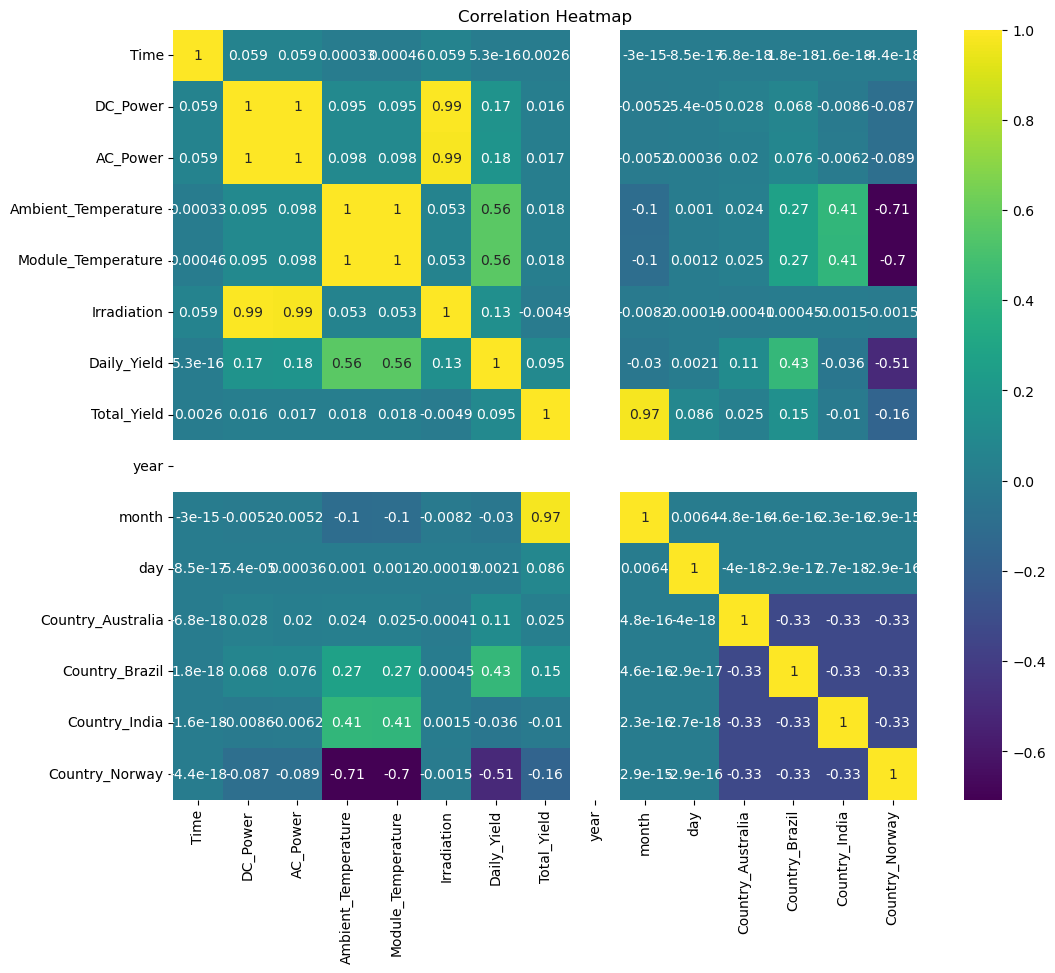

In [81]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix, annot=True, cmap="viridis")

plt.title("Correlation Heatmap")

plt.show()

In [82]:
X = df.drop("Daily_Yield", axis=1) 
y = df["Daily_Yield"].copy()

In [83]:
from sklearn.model_selection import train_test_split

X_train_scaled, X_test_scaled, y_train_l, y_test_l = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_scaled)

X_test_scaled = scaler.transform(X_test_scaled)

In [84]:
from sklearn.linear_model import LinearRegression


fr_model = LinearRegression()
fr_model.fit (X_train_scaled, y_train_l)
print("\nLinear Regression model Training has been completed successfully")



Linear Regression model Training has been completed successfully


In [85]:
y_pred_l = fr_model.predict(X_test_scaled)
print(y_pred_l)


[299.59247119 434.06421703 443.31277247 ... 368.37381646 467.55249362
 463.36321547]


In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_l, y_pred_l)
mse = mean_squared_error(y_test_l, y_pred_l)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_l, y_pred_l)


print(f"\nModel Evaluation\n" + "="*30)
print(f"Mean Absolute Error (MAE):      {mae:.2f}")
print(f"Mean Squared Error (MSE):       {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2):                 {r2:.2f}")


Model Evaluation
Mean Absolute Error (MAE):      47.51
Mean Squared Error (MSE):       3824.71
Root Mean Squared Error (RMSE): 61.84
R-squared (R2):                 0.48


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_r, y_test_r = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [88]:

model_r  = RandomForestRegressor(n_estimators=100, random_state=42)
model_r .fit(X_train, y_train_r) 



,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
y_pred_r = model_r.predict(X_test)
print(y_pred_r)

[175.16916 424.02451 483.99603 ... 361.084   496.43013 480.5204 ]


In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)


print(f"\nModel Evaluation\n" + "="*30)
print(f"Mean Absolute Error (MAE):      {mae:.2f}")
print(f"Mean Squared Error (MSE):       {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2):                 {r2:.2f}")


Model Evaluation
Mean Absolute Error (MAE):      0.83
Mean Squared Error (MSE):       4.21
Root Mean Squared Error (RMSE): 2.05
R-squared (R2):                 1.00


In [93]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred_r)
    mse = mean_squared_error(y_true, y_pred_r)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- تقييم مودل {model_name} ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score (Accuracy): {r2:.4f}")
    print("-" * 30)


evaluate_model(y_test_l, y_pred_l, "Linear Regression")
evaluate_model(y_test_r, y_pred_r, "Random Forest")

--- تقييم مودل Linear Regression ---
Mean Absolute Error (MAE): 0.83
Root Mean Squared Error (RMSE): 2.05
R² Score (Accuracy): 0.4794
------------------------------
--- تقييم مودل Random Forest ---
Mean Absolute Error (MAE): 0.83
Root Mean Squared Error (RMSE): 2.05
R² Score (Accuracy): 0.9994
------------------------------


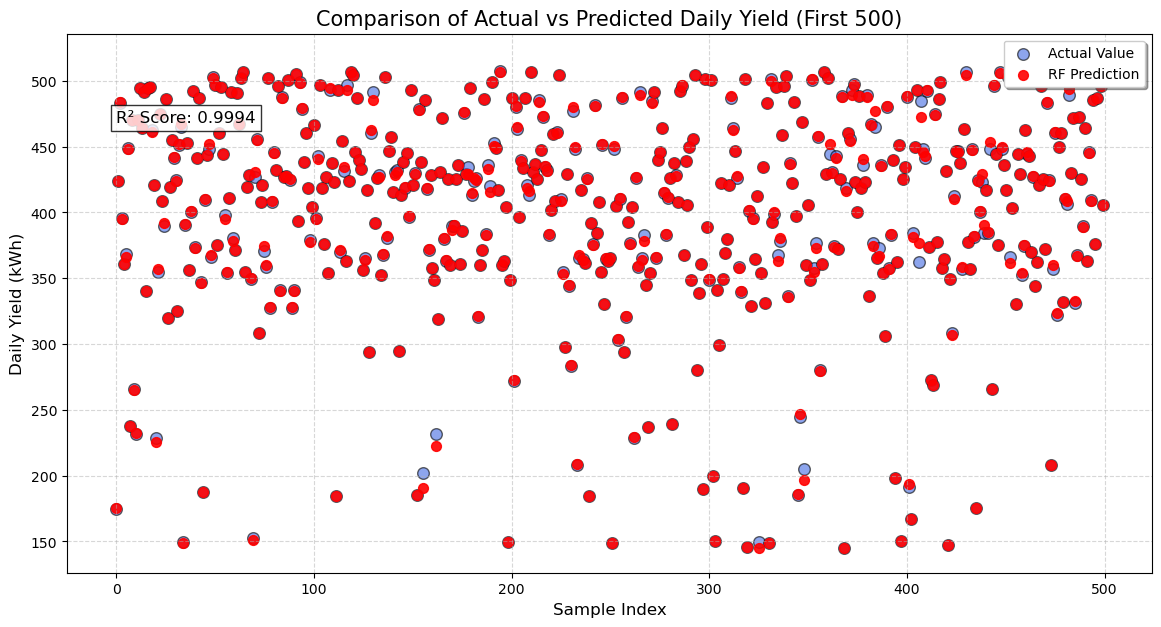

In [94]:
n_samples = 500

plt.figure(figsize=(14, 7))


plt.scatter(range(n_samples), y_test_r[:n_samples], 
            color='royalblue', label='Actual Value', 
            alpha=0.6, s=70, edgecolors='k')


plt.scatter(range(n_samples), y_pred_r[:n_samples], 
            color='red', label='RF Prediction', 
            marker='o', s=50, alpha=0.9)


plt.title('Comparison of Actual vs Predicted Daily Yield (First 500)', fontsize=15)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Daily Yield (kWh)', fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.text(0, y_test_r.max()*0.9, f"R² Score: {r2_score(y_test_r, y_pred_r):.4f}", 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

plt.show()

In [95]:
import joblib


with open(r'C:\Users\zxc91\Desktop\Anaconda\AI_COURSE\anacnda مشاريع\المشروع 2.pkl', 'wb') as f:
    joblib.dump(model_r)


with open(r'C:\Users\zxc91\Desktop\Anaconda\AI_COURSE\anacnda مشاريع\المشروع 2.pkl', 'rb') as f:
    loaded_job = joblib.load()


print(f"Pickle R^2 Score: {loaded_job.score(X_test, y_test_r)}")

Pickle R^2 Score: 0.9994273589930062
